### Sanity check
- nan values
- mean
- L2 X - Y[0]

### Data variance check
- X pca + cumsum explained variance
- Y pca + cumsum explained variance
- Y variance over time

### Predictability (linear) check
- R2 score Y_red Y pred

In [4]:
from dataset_loader import LDCDataset
import torch
import torch.nn.functional as F
import numpy as np

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [15]:
def analyse_ds(ds):
    L2 = torch.nn.MSELoss(reduction="mean")
    data_x = ds.X[..., :3]
    print(f'X NaN: {torch.isnan(data_x.sum()):1d}')
    print(f'X mean: {torch.mean(data_x):.4f}')
    
    print(f'L2 X, Y[0]: {L2(ds.Y[:, 0], data_x):.4f}')
    print(f'Y NaN: {torch.isnan(ds.Y.sum()):1d}')
    print(f'Y mean: {torch.mean(ds.Y):.4f}')
    


    print(f'X var: {torch.var(data_x):.4f}')
    print(f'Y var: {torch.var(ds.Y):.4f}')
    plt.plot(torch.var(ds.Y, axis=(0, 2, 3, 4)))
    plt.title("Variance over time")
    plt.xlabel("Time sample")
    plt.ylabel("Variance")
    plt.show()

    B, X, _, C = data_x.shape
    X_pca = data_x.reshape(B, X*X*C)
    pca = PCA()
    Z = pca.fit_transform(X_pca)
    plt.scatter(Z[:,0], Z[:,1], c=range(len(Z)))
    plt.colorbar()
    plt.title("X PCA")
    plt.xlabel("First component")
    plt.ylabel("Second component")
    plt.show()
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    plt.title("Cumulative explained variance of X")
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.ylim(0, 1)
    plt.show()

    B, T, X, _, C = ds.Y.shape
    Y_pca = ds.Y.reshape(B, T*X*X*C)

    pca = PCA()
    Z = pca.fit_transform(Y_pca)
    plt.scatter(Z[:,0], Z[:,1], c=range(len(Z)))
    plt.colorbar()
    plt.title("Y PCA")
    plt.xlabel("First component")
    plt.ylabel("Second component")
    plt.show()
    
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    plt.title("Cumulative explained variance of Y")
    plt.xlabel("component")
    plt.ylabel("Explained variance ratio")
    plt.ylim(0, 1)
    plt.show()

    pca_y = PCA(n_components=min(50, B))
    Y_red = pca_y.fit_transform(Y_pca)
    
    model = LinearRegression().fit(X_pca, Y_red)
    Y_pred = model.predict(X_pca)
    
    print("Linear Predictability:", r2_score(Y_red, Y_pred))

In [37]:
def analyse_ds_compact(ds):
    L2 = torch.nn.MSELoss(reduction="mean")
    data_x = ds.X[..., :3]
    print(f'X NaN: {torch.isnan(data_x.sum()):1d}')
    print(f'X mean: {torch.mean(data_x):.4f}')
    
    print(f'L2 X, Y[0]: {L2(ds.Y[:, 0], data_x):.4f}')
    print(f'Y NaN: {torch.isnan(ds.Y.sum()):1d}')
    print(f'Y mean: {torch.mean(ds.Y):.4f}')
    


    print(f'X var: {torch.var(data_x):.4f}')
    print(f'Y var: {torch.var(ds.Y):.4f}')
    plt.plot(torch.var(ds.Y, axis=(0, 2, 3, 4)))
    plt.title("Variance over time")
    plt.xlabel("Time sample")
    plt.ylabel("Variance")
    plt.show()

    B, X, _, C = data_x.shape
    X_pca = data_x.reshape(B, X*X*C)
    xpca = PCA()
    ZX = xpca.fit_transform(X_pca)

    B, T, X, _, C = ds.Y.shape
    Y_pca = ds.Y.reshape(B, T*X*X*C)
    ypca = PCA()
    ZY = ypca.fit_transform(Y_pca)

    plt.scatter(ZX[:,0], ZX[:,1], label="X", marker='o', c=range(len(ZX)))
    plt.scatter(ZY[:,0], ZY[:,1], label="Y", marker='x', c=range(len(ZY)))
    plt.colorbar()
    plt.title("PCA")
    plt.xlabel("First component")
    plt.ylabel("Second component")
    plt.legend()
    plt.show()

    plt.plot(np.cumsum(xpca.explained_variance_ratio_), marker='o', label="X")
    plt.plot(np.cumsum(ypca.explained_variance_ratio_), marker='o', label="Y")
    line = np.arange(1, 100.0, 1)
    log = np.log(line)
    log = log / max(log)
    plt.plot(line, log, label='log shape comparison')
    plt.title("Cumulative explained variance of the dataset")
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()

    # pca_y = PCA(n_components=min(50, B))
    # Y_red = pca_y.fit_transform(Y_pca)
    
    # model = LinearRegression().fit(X_pca, Y_red)
    # Y_pred = model.predict(X_pca)
    
    # print("Linear Predictability:", r2_score(Y_red, Y_pred))

In [38]:
# dataset = LDCDataset("ds3", 65, 100)

In [39]:
# analyse_ds(dataset)

In [25]:
ds4 = LDCDataset("ds4", 65)

X NaN: 0
X mean: 0.0034
L2 X, Y[0]: 0.0000
Y NaN: 0
Y mean: 0.0028
X var: 0.0105
Y var: 0.0157


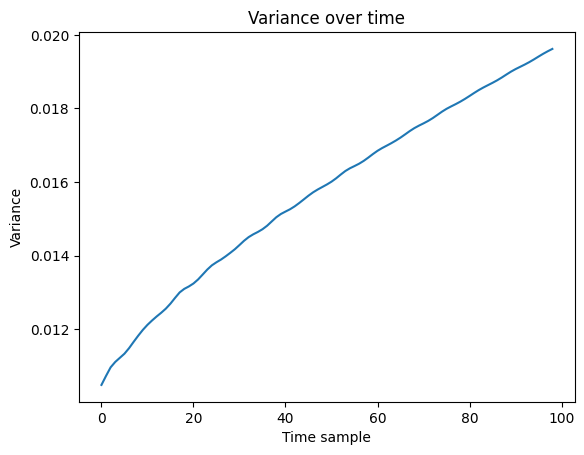

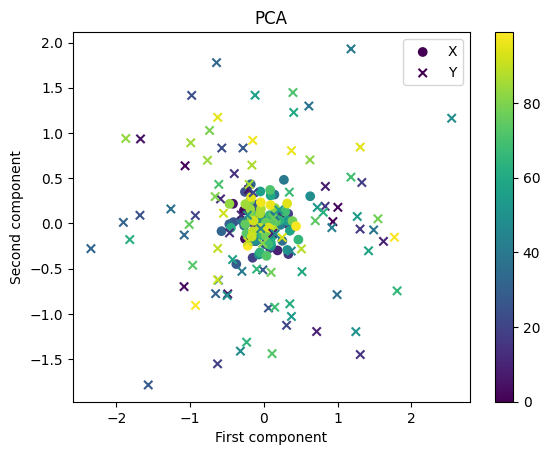

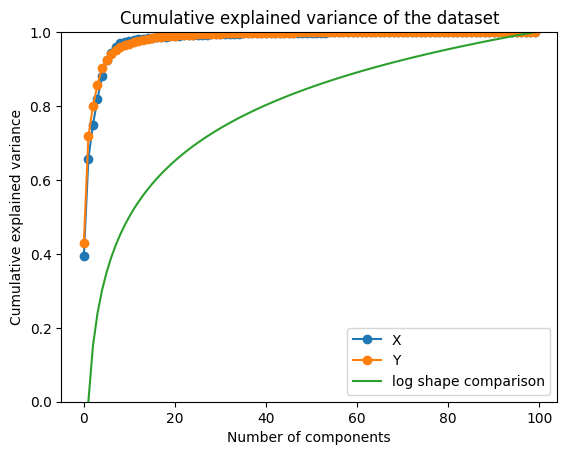

In [40]:
analyse_ds_compact(ds4)

X NaN: 0
X mean: 0.0034
L2 X, Y[0]: 0.0000
Y NaN: 0
Y mean: 0.0028
X var: 0.0105
Y var: 0.0158


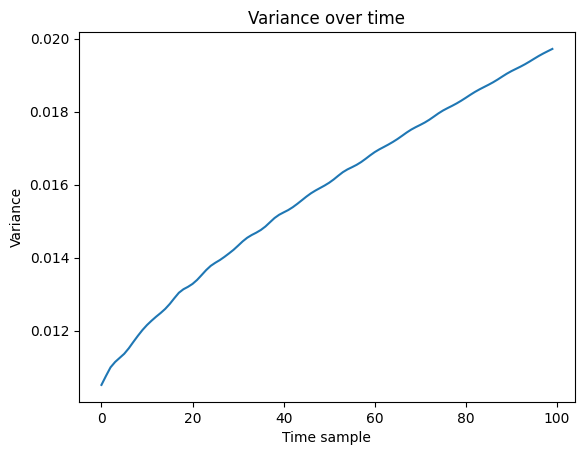

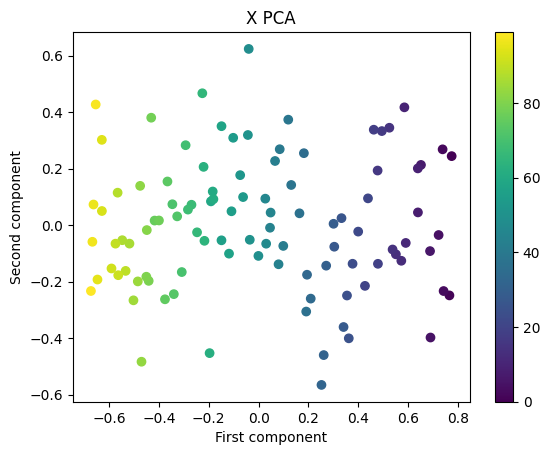

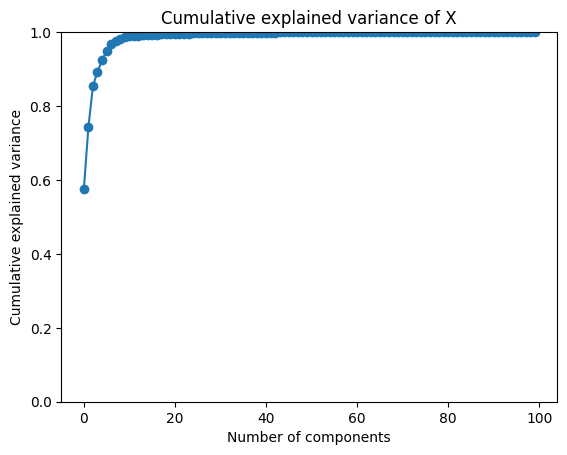

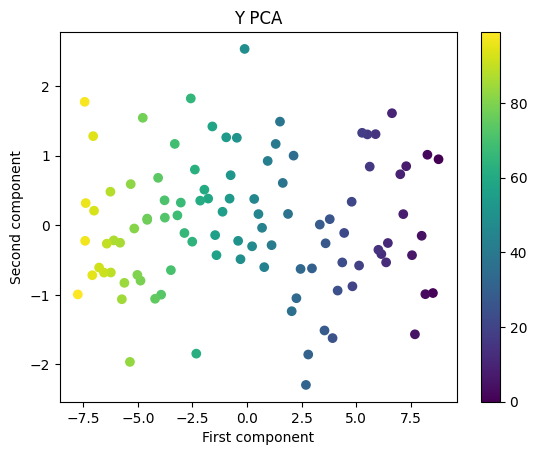

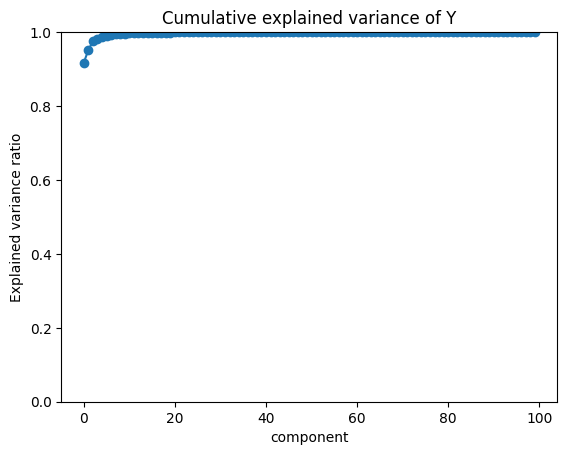

Linear Predictability: 1.0


In [6]:
analyse_ds(LDCDataset("ds5", 65))

X NaN: 0
X mean: 0.0034
L2 X, Y[0]: 0.0000
Y NaN: 0
Y mean: 0.0028
X var: 0.0105
Y var: 0.0158


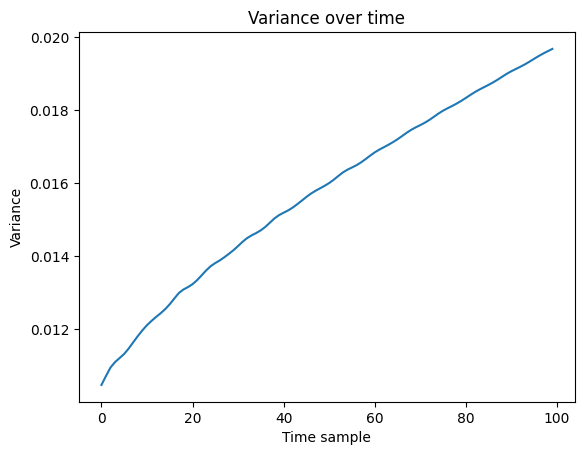

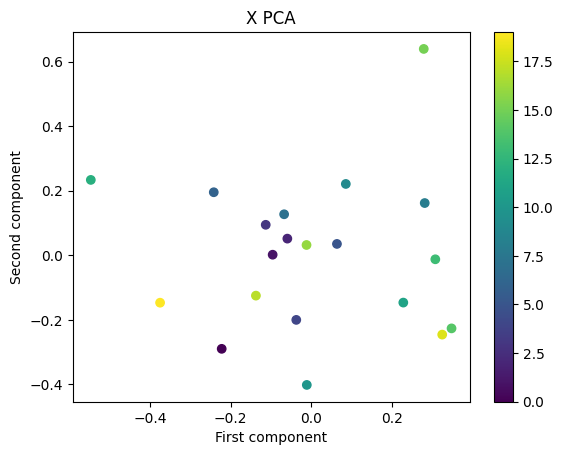

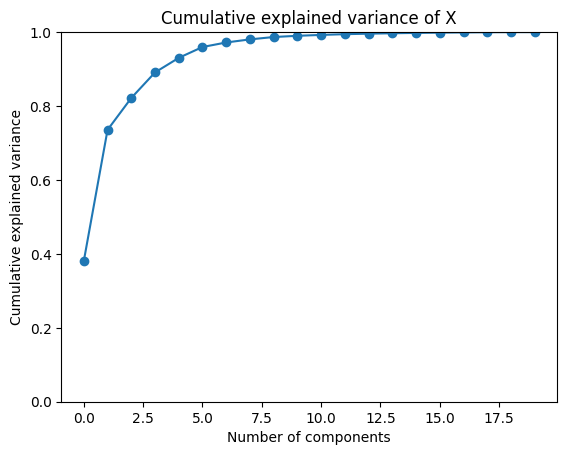

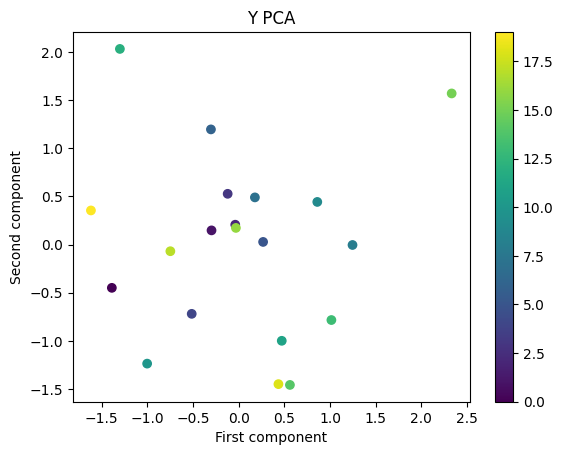

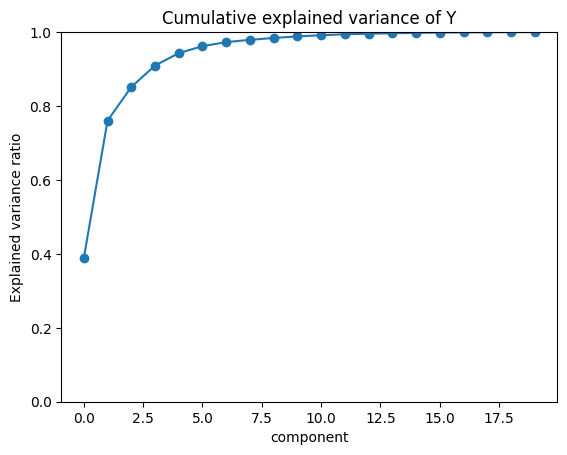

Linear Predictability: 1.0


In [9]:
analyse_ds(LDCDataset("tst_re500", 65))